In [94]:
# ==========================================
# STEP 2: IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import linregress

# Plot style
plt.style.use("ggplot")

In [95]:
# ==========================================
# SECTION 1: LOAD PROCESSED DATA
# ==========================================

from pathlib import Path

# Path to processed data folder
data_path = Path("../data/processed")

In [96]:
# Get all CSV files
csv_files = list(data_path.glob("*.csv"))

print("Total CSV files:", len(csv_files))

Total CSV files: 10


In [97]:
for file in csv_files:
    print(file.name)

01_fund_master_clean.csv
02_nav_history_clean.csv
03_aum_by_fund_house_clean.csv
04_monthly_sip_inflows_clean.csv
05_category_inflows_clean.csv
06_industry_folio_count_clean.csv
07_scheme_performance_clean.csv
08_investor_transactions_clean.csv
09_portfolio_holdings_clean.csv
10_benchmark_indices_clean.csv


In [98]:
# Dictionary to store all dataframes
funds = {}

for file in csv_files:
    df = pd.read_csv(file)

    # Remove .csv extension
    fund_name = file.stem

    funds[fund_name] = df

print("Files Loaded Successfully:", len(funds))

Files Loaded Successfully: 10


In [99]:
print(funds.keys())

dict_keys(['01_fund_master_clean', '02_nav_history_clean', '03_aum_by_fund_house_clean', '04_monthly_sip_inflows_clean', '05_category_inflows_clean', '06_industry_folio_count_clean', '07_scheme_performance_clean', '08_investor_transactions_clean', '09_portfolio_holdings_clean', '10_benchmark_indices_clean'])


In [100]:
first_fund = list(funds.keys())[0]

print("First Fund:", first_fund)

funds[first_fund].head()

First Fund: 01_fund_master_clean


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [101]:
# ==========================================
# SECTION 2: CHECK AVAILABLE FILES
# ==========================================

from pathlib import Path

# Processed data folder
data_path = Path("../data/processed")

# List all CSV files
csv_files = sorted(data_path.glob("*.csv"))

print(f"Total CSV files found: {len(csv_files)}")

for file in csv_files:
    print(file.name)

Total CSV files found: 10
01_fund_master_clean.csv
02_nav_history_clean.csv
03_aum_by_fund_house_clean.csv
04_monthly_sip_inflows_clean.csv
05_category_inflows_clean.csv
06_industry_folio_count_clean.csv
07_scheme_performance_clean.csv
08_investor_transactions_clean.csv
09_portfolio_holdings_clean.csv
10_benchmark_indices_clean.csv


In [102]:
# ==========================================
# SECTION 3: LOAD NAV HISTORY DATA
# ==========================================

nav_df = pd.read_csv("../data/processed/02_nav_history_clean.csv")

print("Shape:", nav_df.shape)

nav_df.head()

Shape: (46000, 3)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [103]:
# ==========================================
# SECTION 5: DAILY RETURN CALCULATION
# ==========================================

# Calculate daily return for each fund
nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
          .pct_change()
)

# Display first few rows
nav_df.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [104]:
# Summary statistics of daily returns
nav_df["daily_return"].describe()


count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

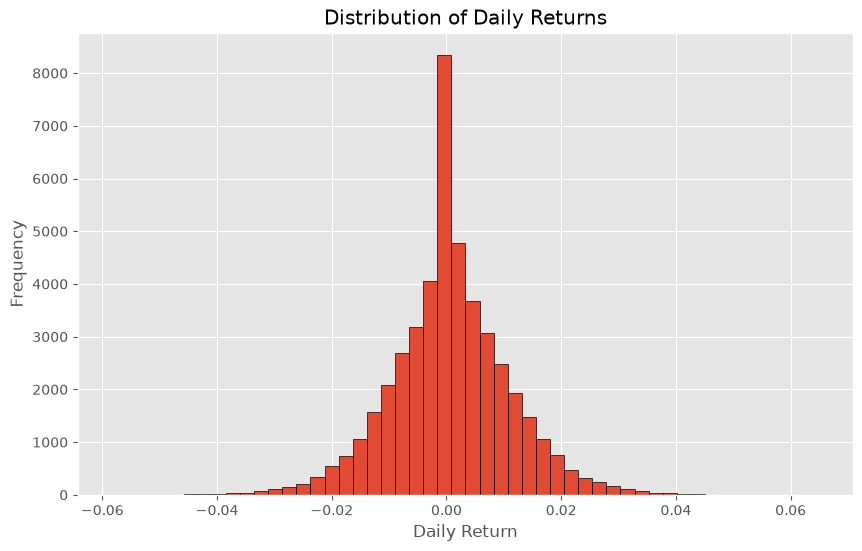

In [105]:
# ==========================================
# SECTION 6: DAILY RETURN DISTRIBUTION
# ==========================================

plt.figure(figsize=(10, 6))

plt.hist(
    nav_df["daily_return"].dropna(),
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7212\2312531905.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


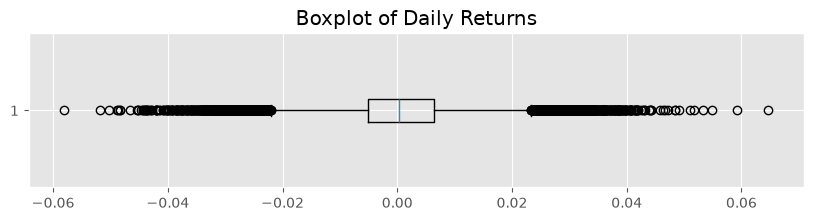

In [106]:
plt.figure(figsize=(10, 2))

plt.boxplot(
    nav_df["daily_return"].dropna(),
    vert=False
)

plt.title("Boxplot of Daily Returns")

plt.show()

### Observation

- Daily returns are concentrated around zero.
- Most returns fall within a small range, indicating normal day-to-day market movement.
- A few outliers are present, representing periods of high market volatility.
- Overall, the return distribution appears reasonable for mutual fund NAV data.

In [107]:
# ==========================================
# SECTION 7: CHECK DATE RANGE
# ==========================================

print("Earliest Date :", nav_df["date"].min())
print("Latest Date   :", nav_df["date"].max())

Earliest Date : 2022-01-03
Latest Date   : 2026-05-29


In [108]:
print("Total Funds:", nav_df["amfi_code"].nunique())

Total Funds: 40


In [109]:
# ==========================================
# SECTION 7: CAGR CALCULATION
# ==========================================

cagr_results = []

In [110]:
for fund_code, fund_data in nav_df.groupby("amfi_code"):

    # Sort by date
    fund_data = fund_data.sort_values("date")

    # Convert date to datetime
    fund_data["date"] = pd.to_datetime(fund_data["date"], errors="coerce")
    fund_data = fund_data.dropna(subset=["date"])

    # Latest NAV
    latest_date = fund_data["date"].max()
    latest_nav = fund_data.iloc[-1]["nav"]

    result = {
        "amfi_code": fund_code
    }

    for years in [1, 3, 5]:

        target_date = latest_date - pd.DateOffset(years=years)

        historical_data = fund_data[fund_data["date"] <= target_date]

In [111]:
# Check data type
print(nav_df["date"].dtype)

# Convert date column to datetime
nav_df["date"] = pd.to_datetime(nav_df["date"])

# Check again
print(nav_df["date"].dtype)

str
datetime64[us]


In [112]:
nav_df["date"] = pd.to_datetime(nav_df["date"])
nav_df = nav_df.sort_values(["amfi_code", "date"]).reset_index(drop=True)

In [113]:
print(nav_df["date"].dtype)

datetime64[us]


In [114]:
# ==========================================
# SECTION 7: CAGR CALCULATION
# ==========================================

cagr_results = []

In [ ]:
import pandas as pd
import numpy as np

# Convert date column to datetime
nav_df["date"] = pd.to_datetime(nav_df["date"], errors="coerce")

cagr_results = []

for fund_code, fund_data in nav_df.groupby("amfi_code"):

    fund_data = fund_data.sort_values("date").reset_index(drop=True)

    latest_date = fund_data["date"].max()
    latest_nav = fund_data.iloc[-1]["nav"]

    fund_result = {
        "amfi_code": fund_code
    }

    for years in [1, 3, 5]:

        target_date = latest_date - pd.DateOffset(years=years)

        temp = fund_data[fund_data["date"] <= target_date]

        if len(temp) == 0:
            fund_result[f"CAGR_{years}Y"] = np.nan
        else:
            start_nav = temp.iloc[-1]["nav"]

            cagr = ((latest_nav / start_nav) ** (1 / years)) - 1

            fund_result[f"CAGR_{years}Y"] = cagr * 100

    cagr_results.append(fund_result)

cagr_df = pd.DataFrame(cagr_results)

cagr_df = cagr_df.merge(
    schemes[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"

)

cagr_df.head()

NameError: name 'fund_master_df' is not defined

In [ ]:
cagr_df = pd.DataFrame(cagr_results)

cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,149324,65.138719,27.000427,NaN


In [ ]:
cagr_df = cagr_df.round(2)

cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,149324,65.14,27.0,NaN


In [ ]:
cagr_df.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

print("CAGR comparison table saved successfully.")

CAGR comparison table saved successfully.


In [ ]:
# ==========================================
# SECTION 8: SHARPE RATIO
# ==========================================

# Annual Risk-Free Rate
risk_free_rate = 0.065

# Daily Risk-Free Rate
daily_rf = risk_free_rate / 252

print("Daily Risk-Free Rate:", daily_rf)

Daily Risk-Free Rate: 0.00025793650793650796


In [ ]:
sharpe_results = []

for fund_code, fund_data in nav_df.groupby("amfi_code"):

    # Remove missing returns
    returns = fund_data["daily_return"].dropna()

    # Skip funds with insufficient data
    if len(returns) < 2:
        continue

    mean_return = returns.mean()
    std_return = returns.std()

    sharpe_ratio = ((mean_return - daily_rf) / std_return) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": fund_code,
        "Sharpe_Ratio": sharpe_ratio
    })

In [ ]:
sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df.head()

,amfi_code,Sharpe_Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [ ]:
sharpe_df["Sharpe_Rank"] = (
    sharpe_df["Sharpe_Ratio"]
    .rank(ascending=False, method="dense")
)

sharpe_df = sharpe_df.sort_values("Sharpe_Rank")

sharpe_df.head(10)

,amfi_code,Sharpe_Ratio,Sharpe_Rank
34,148567,1.448291,1.0
30,120843,1.306744,2.0
36,148569,1.234930,3.0
19,119551,1.208267,4.0
25,120505,1.180101,5.0
38,149323,1.132122,6.0
2,100033,1.093699,7.0
9,118632,1.081659,8.0
3,101206,1.027213,9.0
24,120504,1.026524,10.0


In [ ]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio saved successfully.")

Sharpe Ratio saved successfully.


In [ ]:
# ==========================================
# SECTION 9: SORTINO RATIO
# ==========================================

sortino_results = []

for fund_code, fund_data in nav_df.groupby("amfi_code"):

    returns = fund_data["daily_return"].dropna()

    # Keep only negative returns
    downside_returns = returns[returns < 0]

    if len(downside_returns) < 2:
        continue

    mean_return = returns.mean()
    downside_std = downside_returns.std()

    sortino_ratio = (
        (mean_return - daily_rf)
        / downside_std
    ) * np.sqrt(252)

    sortino_results.append({
        "amfi_code": fund_code,
        "Sortino_Ratio": sortino_ratio
    })

In [ ]:
sortino_df = pd.DataFrame(sortino_results)

sortino_df.head()

,amfi_code,Sortino_Ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [ ]:
sortino_df["Sortino_Rank"] = (
    sortino_df["Sortino_Ratio"]
    .rank(
        ascending=False,
        method="dense"
    )
)

sortino_df = sortino_df.sort_values("Sortino_Rank")

sortino_df.head(10)

,amfi_code,Sortino_Ratio,Sortino_Rank
34,148567,2.385644,1.0
30,120843,2.364320,2.0
36,148569,2.146914,3.0
19,119551,2.140267,4.0
25,120505,2.029353,5.0
38,149323,1.875101,6.0
9,118632,1.850133,7.0
2,100033,1.829134,8.0
24,120504,1.805294,9.0
3,101206,1.799563,10.0


In [ ]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

print("Sortino Ratio saved successfully.")

Sortino Ratio saved successfully.


In [ ]:
# ==========================================
# SECTION 10: LOAD BENCHMARK DATA
# ==========================================

benchmark_df = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

print("Shape:", benchmark_df.shape)

benchmark_df.head()

Shape: (8050, 3)


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [ ]:
print(benchmark_df.columns)

Index(['date', 'index_name', 'close_value'], dtype='str')


In [ ]:
# ==========================================
# SECTION 10: CHECK AVAILABLE BENCHMARKS
# ==========================================

print(benchmark_df["index_name"].unique())

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [ ]:
print(benchmark_df["index_name"].unique())

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [ ]:
# ==========================================
# SECTION 10: FILTER NIFTY100
# ==========================================

nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

# Convert date to datetime
nifty100["date"] = pd.to_datetime(nifty100["date"])

# Sort by date
nifty100 = nifty100.sort_values("date")

# Display first rows
nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [ ]:
# Calculate benchmark daily returns

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [ ]:
# ==========================================
# ALPHA & BETA CALCULATION
# ==========================================

alpha_beta_results = []

for fund_code, fund_data in nav_df.groupby("amfi_code"):

    # Merge fund returns with benchmark returns
    merged = pd.merge(
        fund_data,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    # Remove missing values
    merged = merged.dropna(subset=["daily_return", "benchmark_return"])

    # Skip if insufficient data
    if len(merged) < 2:
        continue

    # Linear Regression
    result = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta_results.append({
        "amfi_code": fund_code,
        "Alpha": result.intercept * 252,
        "Beta": result.slope
    })

In [ ]:
alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [ ]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("Alpha & Beta saved successfully.")

Alpha & Beta saved successfully.


In [ ]:
# ==========================================
# SECTION 11: MAXIMUM DRAWDOWN
# ==========================================

mdd_results = []

for fund_code, fund_data in nav_df.groupby("amfi_code"):

    fund_data = fund_data.sort_values("date").copy()

    # Running maximum NAV
    fund_data["running_max"] = fund_data["nav"].cummax()

    # Drawdown
    fund_data["drawdown"] = (
        fund_data["nav"] /
        fund_data["running_max"]
    ) - 1

    # Maximum Drawdown
    max_dd = fund_data["drawdown"].min()

    # Worst drawdown date
    bottom_date = fund_data.loc[
        fund_data["drawdown"].idxmin(),
        "date"
    ]

    mdd_results.append({
        "amfi_code": fund_code,
        "Maximum_Drawdown": max_dd,
        "Worst_Date": bottom_date
    })

In [ ]:
mdd_df = pd.DataFrame(mdd_results)

mdd_df.head()

,amfi_code,Maximum_Drawdown,Worst_Date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [ ]:
mdd_df["Drawdown_Rank"] = (
    mdd_df["Maximum_Drawdown"]
    .rank(
        ascending=False,
        method="dense"
    )
)

mdd_df = mdd_df.sort_values("Drawdown_Rank")

mdd_df.head(10)

,amfi_code,Maximum_Drawdown,Worst_Date,Drawdown_Rank
27,120507,-0.000977,2025-10-20,1.0
31,120844,-0.001163,2024-04-30,2.0
5,101208,-0.001622,2023-09-12,3.0
1,100025,-0.043083,2023-07-28,4.0
18,119120,-0.043287,2025-04-01,5.0
13,118636,-0.083164,2024-02-09,6.0
6,102885,-0.108599,2022-03-29,7.0
34,148567,-0.112657,2023-10-20,8.0
3,101206,-0.112916,2023-07-05,9.0
12,118635,-0.116506,2022-06-09,10.0


In [ ]:
mdd_df.to_csv(
    "../reports/maximum_drawdown.csv",
    index=False
)

print("Maximum Drawdown saved successfully.")

Maximum Drawdown saved successfully.


In [ ]:
# ==========================================
# SECTION 12: LOAD EXPENSE RATIO
# ==========================================

expense_df = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

expense_df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,expense_ratio_flag
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False


In [ ]:
print(expense_df.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade', 'expense_ratio_flag'],
      dtype='str')


In [ ]:
print(expense_df.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade', 'expense_ratio_flag'],
      dtype='str')


In [ ]:
# ==========================================
# SECTION 12: FUND SCORECARD
# ==========================================

expense_df = expense_df[
    ["amfi_code", "expense_ratio_pct"]
]

expense_df.head()

,amfi_code,expense_ratio_pct
0,119551,1.54
1,119552,0.66
2,119598,1.43
3,119599,0.72
4,119120,0.77


In [ ]:
expense_df["Expense_Rank"] = (
    expense_df["expense_ratio_pct"]
    .rank(
        ascending=True,
        method="dense"
    )
)

expense_df.head()

,amfi_code,expense_ratio_pct,Expense_Rank
0,119551,1.54,24.0
1,119552,0.66,4.0
2,119598,1.43,18.0
3,119599,0.72,5.0
4,119120,0.77,8.0


In [ ]:
cagr_df["CAGR_Rank"] = (
    cagr_df["CAGR_3Y"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [ ]:
alpha_beta_df["Alpha_Rank"] = (
    alpha_beta_df["Alpha"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [ ]:
mdd_df["Drawdown_Rank"] = (
    mdd_df["Maximum_Drawdown"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [ ]:
scorecard = (
    cagr_df
    .merge(
        sharpe_df[
            ["amfi_code", "Sharpe_Rank"]
        ],
        on="amfi_code"
    )
    .merge(
        alpha_beta_df[
            ["amfi_code", "Alpha_Rank"]
        ],
        on="amfi_code"
    )
    .merge(
        expense_df[
            ["amfi_code", "Expense_Rank"]
        ],
        on="amfi_code"
    )
    .merge(
        mdd_df[
            ["amfi_code", "Drawdown_Rank"]
        ],
        on="amfi_code"
    )
)

scorecard.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,CAGR_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank
0,149324,65.14,27.0,NaN,1.0,13.0,2.0,22.0,37.0


In [ ]:
scorecard["Fund_Score"] = (
      (41 - scorecard["CAGR_Rank"]) * 0.30
    + (41 - scorecard["Sharpe_Rank"]) * 0.25
    + (41 - scorecard["Alpha_Rank"]) * 0.20
    + (41 - scorecard["Expense_Rank"]) * 0.15
    + (41 - scorecard["Drawdown_Rank"]) * 0.10
)

In [ ]:
scorecard["Fund_Score"] = (
    scorecard["Fund_Score"]
    / scorecard["Fund_Score"].max()
) * 100

scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
)

scorecard.head(10)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,CAGR_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Fund_Score
0,149324,65.14,27.0,NaN,1.0,13.0,2.0,22.0,37.0,100.0


In [ ]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard saved successfully.")

Fund Scorecard saved successfully.


In [ ]:
# ==========================================
# SECTION 13: TOP 5 FUNDS
# ==========================================

top5 = scorecard.head(5)

print(top5[["amfi_code", "Fund_Score"]])

   amfi_code  Fund_Score
0     149324       100.0


In [ ]:
fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")

fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [ ]:
top5 = top5.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

top5

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,CAGR_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Fund_Score,scheme_name
0,149324,65.14,27.0,NaN,1.0,13.0,2.0,22.0,37.0,100.0,DSP Small Cap Fund - Regular - Growth


In [ ]:
# ==========================================
# SECTION 13: BENCHMARK COMPARISON
# ==========================================

top5_codes = top5["amfi_code"].tolist()

print(top5_codes)

[149324]


In [ ]:
top5_nav = nav_df[
    nav_df["amfi_code"].isin(top5_codes)
].copy()

top5_nav.head()

,amfi_code,date,nav,daily_return
44850,149324,2022-01-03,81.6814,NaN
44851,149324,2022-01-04,80.8239,-0.010498
44852,149324,2022-01-05,80.6143,-0.002593
44853,149324,2022-01-06,79.9386,-0.008382
44854,149324,2022-01-07,80.8723,0.011680


In [ ]:
latest_date = nav_df["date"].max()

start_date = latest_date - pd.DateOffset(years=3)

top5_nav = top5_nav[
    top5_nav["date"] >= start_date
]

In [ ]:
top5_nav["Normalized_NAV"] = (
    top5_nav.groupby("amfi_code")["nav"]
    .transform(lambda x: 100 * x / x.iloc[0])
)

In [ ]:
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

benchmarks = benchmark_df[
    benchmark_df["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

benchmarks = benchmarks[
    benchmarks["date"] >= start_date
]

Prepare Benchmark Data

In [ ]:
benchmarks["Normalized_Value"] = (
    benchmarks.groupby("index_name")["close_value"]
    .transform(lambda x: 100 * x / x.iloc[0])
)

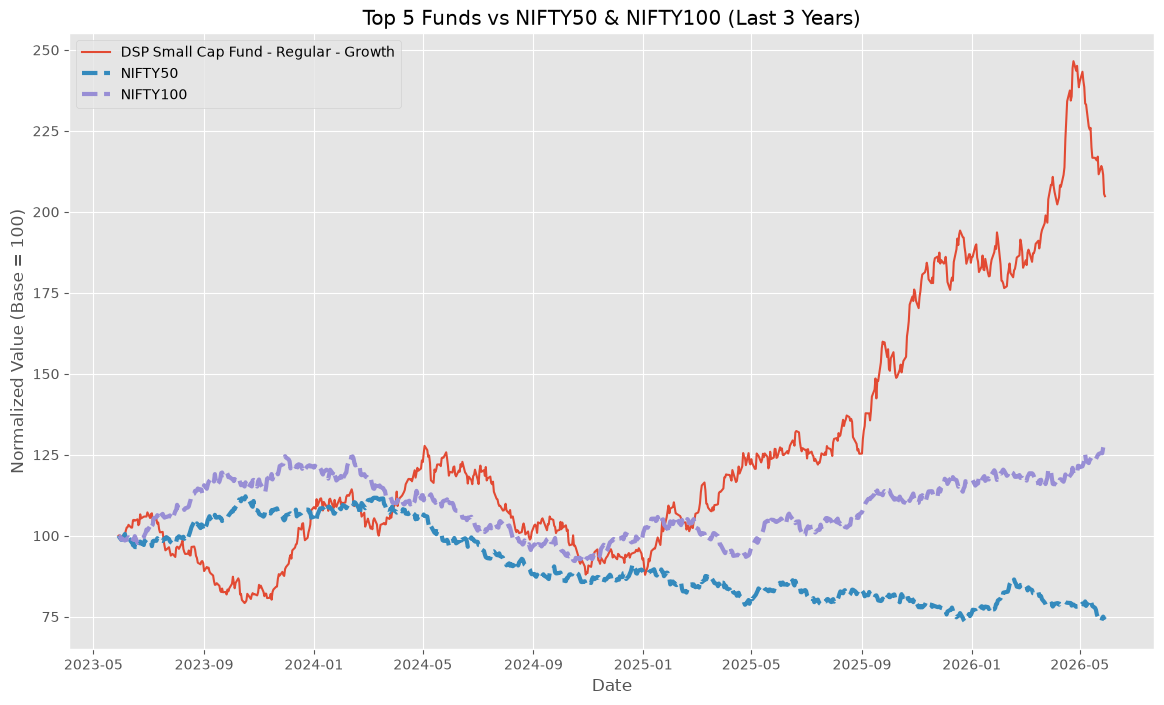

In [ ]:
plt.figure(figsize=(14,8))

# Plot Top 5 Funds
for code in top5_codes:

    fund = top5_nav[
        top5_nav["amfi_code"] == code
    ]

    name = top5.loc[
        top5["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    plt.plot(
        fund["date"],
        fund["Normalized_NAV"],
        label=name
    )

# Plot Benchmarks
for idx in ["NIFTY50", "NIFTY100"]:

    temp = benchmarks[
        benchmarks["index_name"] == idx
    ]

    plt.plot(
        temp["date"],
        temp["Normalized_Value"],
        linewidth=3,
        linestyle="--",
        label=idx
    )

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100 (Last 3 Years)")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")
plt.legend()
plt.grid(True)

plt.savefig("../reports/benchmark_comparison.png")
# Save chart in reports folder
plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
# ==========================================
# SECTION 14: PREPARE BENCHMARK
# ==========================================

nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

nifty100["date"] = pd.to_datetime(nifty100["date"])

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [ ]:
# ==========================================
# SECTION 14: TRACKING ERROR
# ==========================================

tracking_results = []

for fund_code, fund_data in nav_df.groupby("amfi_code"):

    # Merge fund and benchmark returns
    merged = pd.merge(
        fund_data,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    # Remove missing values
    merged = merged.dropna(
        subset=["daily_return", "benchmark_return"]
    )

    if len(merged) < 2:
        continue

    # Tracking Error
    tracking_error = (
        (merged["daily_return"] - merged["benchmark_return"]).std()
        * np.sqrt(252)
    )

    tracking_results.append({
        "amfi_code": fund_code,
        "Tracking_Error": tracking_error
    })

tracking_error_df = pd.DataFrame(tracking_results)

tracking_error_df.head()


,amfi_code,Tracking_Error
0,100016,0.199284
1,100025,0.134535
2,100033,0.228699
3,101206,0.192706
4,101207,0.292117


In [ ]:
tracking_error_df["Tracking_Rank"] = (
    tracking_error_df["Tracking_Error"]
    .rank(
        ascending=True,
        method="dense"
    )
)

tracking_error_df = tracking_error_df.sort_values("Tracking_Rank")

tracking_error_df.head(10)

,amfi_code,Tracking_Error,Tracking_Rank
5,101208,0.128957,1.0
27,120507,0.129044,2.0
31,120844,0.129046,3.0
1,100025,0.134535,4.0
13,118636,0.134758,5.0
18,119120,0.135646,6.0
12,118635,0.183076,7.0
28,120841,0.183119,8.0
6,102885,0.183680,9.0
15,119093,0.187900,10.0


In [ ]:
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print("Tracking Error saved successfully.")

Tracking Error saved successfully.
